In [51]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Load the CSV file into a structured DataFrame

df = pd.read_csv('/Users/jonathancohen1/Desktop/summer26/data/processed/dataset_filled_subjects_new.csv')

#Source : https://www.kaggle.com/datasets/mexwell/us-colleges-and-universities?resource=download
dg =pd.read_csv('/Users/jonathancohen1/Desktop/us-colleges-and-universities.csv', sep=';')

#keep only desired columns
df = df[['name', 'school', 'country', 'year', 'subject_code', 'subject_name', 'predicted_subject_code']]
dg = dg[['NAME', 'CITY', 'STATE']]

#Rename column to match df
dg = dg.rename(columns={'NAME': 'SCHOOL'})

#force school column to be string
df['school'] = df['school'].astype(str)


#from pathlib import Path
#print(Path.cwd())


In [52]:
#found at https://medium.com/@jason_the_data_scientist/python-mapping-state-abbreviations-to-state-and-vice-versa-in-pandas-e4cd24edefb0
abbrev2state = {
        'AK': 'Alaska',
        'AL': 'Alabama',
        'AR': 'Arkansas',
        'AZ': 'Arizona',
        'CA': 'California',
        'CO': 'Colorado',
        'CT': 'Connecticut',
        'DC': 'District of Columbia',
        'DE': 'Delaware',
        'FL': 'Florida',
        'GA': 'Georgia',
        'HI': 'Hawaii',
        'IA': 'Iowa',
        'ID': 'Idaho',
        'IL': 'Illinois',
        'IN': 'Indiana',
        'KS': 'Kansas',
        'KY': 'Kentucky',
        'LA': 'Louisiana',
        'MA': 'Massachusetts',
        'MD': 'Maryland',
        'ME': 'Maine',
        'MI': 'Michigan',
        'MN': 'Minnesota',
        'MO': 'Missouri',
        'MS': 'Mississippi',
        'MT': 'Montana',
        'NC': 'North Carolina',
        'ND': 'North Dakota',
        'NE': 'Nebraska',
        'NH': 'New Hampshire',
        'NJ': 'New Jersey',
        'NM': 'New Mexico',
        'NV': 'Nevada',
        'NY': 'New York',
        'OH': 'Ohio',
        'OK': 'Oklahoma',
        'OR': 'Oregon',
        'PA': 'Pennsylvania',
        'RI': 'Rhode Island',
        'SC': 'South Carolina',
        'SD': 'South Dakota',
        'TN': 'Tennessee',
        'TX': 'Texas',
        'UT': 'Utah',
        'VA': 'Virginia',
        'VT': 'Vermont',
        'WA': 'Washington',
        'WI': 'Wisconsin',
        'WV': 'West Virginia',
        'WY': 'Wyoming',
        'PR': 'Puerto Rico',
        'VI': 'Virgin Islands'
    }
#Replace state abbreviations with full state names
dg['STATE'] = dg['STATE'].replace(abbrev2state)

#make all names upper case for ease
df["school_clean"] = (
    df["school"]
    .str.upper()
    .str.strip()
)

dg["school_clean"] = (
    dg["SCHOOL"]
    .str.upper()
    .str.strip()
)


In [ ]:
#remove countries outside the US
df = df[df['country'] == 'UnitedStates']


#remove country column since now redundant
df = df.drop(columns=['country'])

#remove any rows with missing school
df = df[df['school'].notnull()]



#need replace some errors in the school column! 



#replace empty entries in subject_code column with those from predicted_subject_code column
df.loc[df['subject_code'] == '', 'subject_code'] = df['predicted_subject_code']





#number of unique schools
#distinct_list = df['school'].unique().tolist()
#number of empty strings in the State column
#empty_string_count = (df['State'] == '').sum()
#print(empty_string_count)
#print(distinct_list)



In [54]:
df = df.merge(
    dg[["school_clean", "STATE"]],
    left_on="school_clean",
    right_on="school_clean",
    how="left"
)

df.rename(columns={"STATE": "state"}, inplace=True)

In [55]:
#%pip install rapidfuzz

from rapidfuzz import process, fuzz

school_lookup = dg.set_index("school_clean")["STATE"].to_dict()

def find_state(school):
    if pd.isna(school):
        return None

    match = process.extractOne(
        school,
        school_lookup.keys(),
        scorer=fuzz.token_sort_ratio
    )

    if match and match[1] >= 85:  # threshold
        return school_lookup[match[0]]

    return None

mask = df["state"].isna()

df.loc[mask, "state"] = (
    df.loc[mask, "school_clean"]
      .apply(find_state)
)

In [56]:
#adding in missing values that the above did not catch

df.loc[df['school_clean'] == 'CITY UNIVERSITY OF NEW YORK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLUMBIA UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BUFFALO', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BINGHAMTON', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT ALBANY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT STONY BROOK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLLEGE OF WILLIAM AND MARY', 'state'] = 'Virginia'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE PARK', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS AMHERST', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS, DARTMOUTH', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS LOWELL', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'RADCLIFFE COLLEGE', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PITTSBURGH', 'state'] = 'Pennsylvania'
df.loc[df['school_clean'] == 'UNIVERSITY OF TENNESSEE - KNOXVILLE', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - COLUMBIA', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - KANSAS CITY', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'SOUTHERN ILLINOIS UNIVERSITY AT CARBONDALE', 'state'] = 'Illinois'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, SANTA CRUZ', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF COLORADO AT DENVER', 'state'] = 'Colorado'
df.loc[df['school_clean'] == 'THE OHIO STATE UNIVERSITY', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CINCINNATI', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, BERKELEY', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF ALABAMA-TUSCALOOSA', 'state'] = 'Alabama'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEWARK', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'UNIVERSITY OF MEDICINE AND DENTISTRY OF NEW JERSEY', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEXICO', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE P', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEW BRUNSW', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEX', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'POLYTECHNIC INSTITUTE OF NEW YORK UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'MASSACHUSETTS INSTITUTE OF TECHNOLOGY/WOODS HOLE OCEANOGRAPHIC INSTITUTION', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PUERTO RICO AT MAYAGUEZ', 'state'] = 'Puerto Rico'
df.loc[df['school_clean'] == 'OREGON GRADUATE INSTITUTE OF SCIENCE & TECHNOLOGY', 'state'] = 'Oregon'
df.loc[df['school_clean'] == 'CLAREMONT GRADUATE UNIVERSITY AND SAN DIEGO STATE UNIVERSITY', 'state'] = 'California'
df.loc[df['school_clean'] == 'NEW SCHOOL FOR SOCIAL RESEARCH', 'state'] = 'New York'
df.loc[df['school_clean'] == 'UNIVERSITY OF KANSAS SCHOOL OF BUSINESS', 'state'] = 'Kansas'
df.loc[df['school_clean'] == 'GEORGE PEABODY COLLEGE FOR TEACHERS', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'INDIANA UNIVERSITY-PURDUE UNIVERSITY INDIANAPOLIS', 'state'] = 'Indiana'


#Note Polytechnic University does not uniquely specify a school

#how many empty or NaN values are in the state column
#empty_or_nan = (df['state'].isna() | (df['state'] == "")).sum()
#print(f"Number of empty or NaN values in 'state' column: {empty_or_nan}")

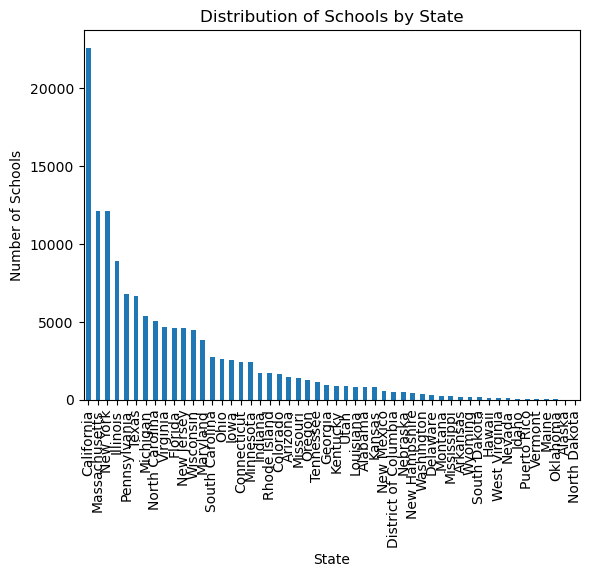

state
Alabama                   837
Alaska                      9
Arizona                  1446
Arkansas                  178
California              22600
Colorado                 1643
Connecticut              2452
Delaware                  331
District of Columbia      494
Florida                  4630
Georgia                   930
Hawaii                    116
Idaho                      73
Illinois                 8894
Indiana                  1728
Iowa                     2545
Kansas                    828
Kentucky                  905
Louisiana                 844
Maine                      44
Maryland                 3861
Massachusetts           12142
Michigan                 5347
Minnesota                2432
Mississippi               241
Missouri                 1418
Montana                   250
Nebraska                  493
Nevada                     91
New Hampshire             404
New Jersey               4610
New Mexico                574
New York                12126
Nort

In [57]:
#make a histogram of the state columns
df['state'].value_counts().plot(kind='bar')
plt.title('Distribution of Schools by State')
plt.xlabel('State')
plt.ylabel('Number of Schools')
plt.show()

#Note some (but not all) of this imbalance may be an artifact of the data entry, rather than the prevalence of schools in each state


# list the number of names from each state
name_counts = df.groupby('state').size()
print(name_counts)

#list as ratio
ratio = name_counts/name_counts.sum()
print(ratio)

#order the states by the number of names
ordered_name_counts = name_counts.sort_values(ascending=False)
print(ordered_name_counts)



In [ ]:
# #In df find the number of entries per year
# #x=df.groupby('year').size()

# #for year, count in x.items():
# #    print(f"Year {year}: {count} entries")

# #in 1929 is first year with 100 entries

# #omit all years before 1929
# df_filtered = df[df['year'] >= 1929]

Year 1792.0: 1 entries
Year 1861.0: 1 entries
Year 1862.0: 1 entries
Year 1863.0: 1 entries
Year 1866.0: 1 entries
Year 1869.0: 1 entries
Year 1870.0: 1 entries
Year 1871.0: 2 entries
Year 1872.0: 1 entries
Year 1873.0: 2 entries
Year 1875.0: 1 entries
Year 1876.0: 4 entries
Year 1877.0: 2 entries
Year 1878.0: 3 entries
Year 1879.0: 1 entries
Year 1880.0: 7 entries
Year 1881.0: 2 entries
Year 1882.0: 1 entries
Year 1883.0: 3 entries
Year 1884.0: 6 entries
Year 1885.0: 8 entries
Year 1886.0: 8 entries
Year 1887.0: 3 entries
Year 1888.0: 6 entries
Year 1889.0: 6 entries
Year 1890.0: 5 entries
Year 1891.0: 10 entries
Year 1892.0: 8 entries
Year 1893.0: 11 entries
Year 1894.0: 12 entries
Year 1895.0: 15 entries
Year 1896.0: 17 entries
Year 1897.0: 19 entries
Year 1898.0: 20 entries
Year 1899.0: 21 entries
Year 1900.0: 20 entries
Year 1901.0: 24 entries
Year 1902.0: 18 entries
Year 1903.0: 10 entries
Year 1904.0: 21 entries
Year 1905.0: 24 entries
Year 1906.0: 23 entries
Year 1907.0: 24 ent

In [58]:
#making a local copy of the csv file to be viewable
#df.to_csv('/Users/jonathancohen1/Desktop/my_data.csv', index=False)


In [59]:
#pie chart for each state showing how popular subjects are

# for state in df['state'].unique():
#     state_df = df[df['state'] == state]
#     subjectcounts = state_df['subject_code'].value_counts()
#     plt.figure(figsize=(10, 8))
#     plt.pie(state_df['subject_code'].value_counts(), labels=state_df['subject_code'].value_counts().index, autopct='%1.1f%%')
#     plt.title(f"Subject Popularity in {state}")
#     plt.show()

In [60]:
# Count dissertations by state/year/subject
counts = (
    df.groupby(['state', 'year', 'subject_code'])
      .size()
      .reset_index(name='count')
)

# Total dissertations per state/year
totals = (
    counts.groupby(['state', 'year'])['count']
          .sum()
          .reset_index(name='total')
)

counts = counts.merge(totals, on=['state', 'year'])

counts['proportion'] = counts['count'] / counts['total']



In [61]:
#pie chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     subject_df = df[df['subject_code'] == subject]
#     statecounts = subject_df['state'].value_counts()
#     plt.figure(figsize=(10, 8))
#     plt.pie(subject_df['state'].value_counts(), labels=subject_df['state'].value_counts().index, autopct='%1.1f%%')
#     plt.title(f"State Popularity for Subject {subject}")
#     plt.show()

In [62]:
# Create a histogram for each state showing how popular subjects are
# for state in df['state'].unique():
#     plt.figure(figsize=(10, 6))
#     df[df['state'] == state].groupby('subject_code').size().plot(kind='bar')
#     plt.title(f'Popularity of Subjects in {state}')
#     plt.xlabel('Subject')
#     plt.ylabel('Count')
#     plt.show()


In [63]:
#histogram chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     plt.figure(figsize=(10, 6))
#     df[df['subject_code'] == subject].groupby('state').size().plot(kind='bar')
#     plt.title(f'Popularity of {subject} by State')
#     plt.xlabel('State')
#     plt.ylabel('Count')
#     plt.show()

In [74]:
# ts = (
#     g.set_index("year")
#      .reindex(years)
#      .rename_axis("year")
#      .reset_index()
# )

# ts["count"] = ts["count"].fillna(0)
# ts["total"] = ts["total"].fillna(0)
# ts["proportion"] = ts["proportion"].fillna(0)

# ts["state"] = state
# ts["subject_code"] = subject

In [73]:
years = range(int(df.year.min()), int(df.year.max()) + 1)

frames = []

for (state, subject), g in counts.groupby(["state", "subject_code"]):

    ts = (
        g.set_index("year")["proportion"]
         .reindex(years, fill_value=0)
         .rename_axis("year")
         .reset_index()
    )

    ts["state"] = state
    ts["subject_code"] = subject

    frames.append(ts)

series = pd.concat(frames, ignore_index=True)

In [76]:
#since time series wasn't working well, we will try multinomial regression


model_df = df[["state", "year", "subject_code"]].copy()

model_df = model_df.dropna()

model_df["subject_code"] = model_df["subject_code"].astype(int)
model_df["year"] = model_df["year"].astype(int)
model_df["state"] = model_df["state"].astype("category")

In [84]:
model_df["subject"] = (
    model_df["subject_code"]
    .astype("category")
)

model_df["y"] = model_df["subject"].cat.codes

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

model_df["year_scaled"] = (
    model_df["year"] - model_df["year"].mean()
) / model_df["year"].std()

X = model_df[["year_scaled", "state"]]
y = model_df["subject_code"]

model = Pipeline([
    ("preprocess",
     ColumnTransformer([
         ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
         ("year", "passthrough", ["year_scaled"])
     ])
    ),
    ("clf",
     LogisticRegression(
         solver="lbfgs",
         max_iter=5000
     )
    )
])

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...), ('year', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [ ]:
#this gives the probabilities of each subject code, given the year and state

probs = model.predict_proba(X)

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

probs_df.head()

,0,1,3,5,6,8,11,12,13,14,...,82,83,85,86,90,91,92,93,94,97
0,0.000239,0.007409,0.013335,0.004468,0.021929,0.005143,0.003990,0.000482,0.009355,0.000270,...,0.018505,0.000620,0.003533,0.002599,0.017139,0.085001,0.011649,0.006079,0.003962,0.020355
1,0.000268,0.006916,0.013786,0.005035,0.021450,0.005146,0.004189,0.000494,0.009864,0.000300,...,0.018346,0.000653,0.003557,0.002682,0.018457,0.088726,0.012644,0.006488,0.004352,0.021164
2,0.000298,0.006430,0.014195,0.005650,0.020896,0.005127,0.004380,0.000503,0.010359,0.000332,...,0.018115,0.000684,0.003567,0.002756,0.019795,0.092238,0.013668,0.006897,0.004762,0.021915
3,0.000415,0.004899,0.015202,0.008063,0.018607,0.004922,0.004939,0.000520,0.011850,0.000452,...,0.016872,0.000780,0.003498,0.002932,0.024290,0.102002,0.017216,0.008213,0.006243,0.023920
4,0.000402,0.005044,0.015128,0.007796,0.018861,0.004952,0.004890,0.000519,0.011715,0.000439,...,0.017026,0.000771,0.003512,0.002919,0.023844,0.101178,0.016856,0.008087,0.006088,0.023757


In [ ]:
#predicted probabilities for each subject code for Iowa in 2025

future = pd.DataFrame({
    "state": ["Iowa"],
    "year_scaled": [(2025 - model_df["year"].mean()) / model_df["year"].std()]
})

p = model.predict_proba(future)

pd.Series(p[0], index=model.named_steps["clf"].classes_)

0     0.001790
1     0.000218
3     0.009002
5     0.042308
6     0.002709
        ...   
91    0.077057
92    0.034969
93    0.010895
94    0.017207
97    0.016357
Length: 63, dtype: float64

In [93]:
years = range(1950, 2031)

future = pd.DataFrame([
    (state, year)
    for state in model_df["state"].unique()
    for year in years
], columns=["state", "year"])

future["year_scaled"] = (
    future["year"] - model_df["year"].mean()
) / model_df["year"].std()

probs = model.predict_proba(future[["state", "year_scaled"]])

result = pd.concat(
    [future.reset_index(drop=True),
     pd.DataFrame(probs, columns=model.named_steps["clf"].classes_)],
    axis=1
)

We will make a some visualization of the geography here, which is based on our predictive model.

In [95]:
#building prediction grid

years = range(1950, 2031)
states = model_df["state"].unique()

future = pd.DataFrame([
    (state, year)
    for state in states
    for year in years
], columns=["state", "year"])

future["year_scaled"] = (
    future["year"] - model_df["year"].mean()
) / model_df["year"].std()


#get predicted probabilities
probs = model.predict_proba(future[["state", "year_scaled"]])

probs_df = pd.DataFrame(
    probs,
    columns=model.named_steps["clf"].classes_
)

result = pd.concat([future.reset_index(drop=True), probs_df], axis=1)

In [96]:
#reduce to top subjects

top_subjects = (
    model_df["subject_code"]
    .value_counts()
    .head(10)
    .index
)

anim_df = result.melt(
    id_vars=["state", "year"],
    value_vars=top_subjects,
    var_name="subject",
    value_name="prob"
)

In [104]:
probs = model.predict_proba(future[["state", "year_scaled"]])

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

result = future.reset_index(drop=True).copy()
result = pd.concat([result, probs_df.reset_index(drop=True)], axis=1)

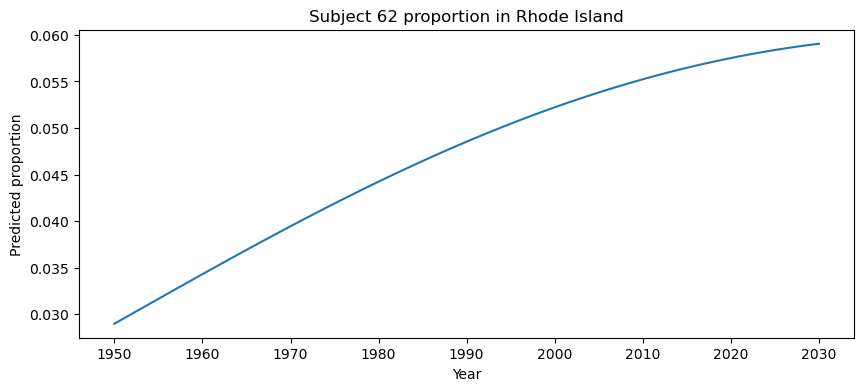

In [117]:
#heatmap 

subject = 62

import seaborn as sns
import matplotlib.pyplot as plt

state = "Rhode Island"

df_hm = result[result["state"] == state]

pivot = df_hm.pivot(index="year", columns="state", values=subject)

plt.figure(figsize=(10,4))
plt.plot(df_hm["year"], df_hm[subject])
plt.title(f"Subject {subject} proportion in {state}")
plt.ylabel("Predicted proportion")
plt.xlabel("Year")
plt.show()

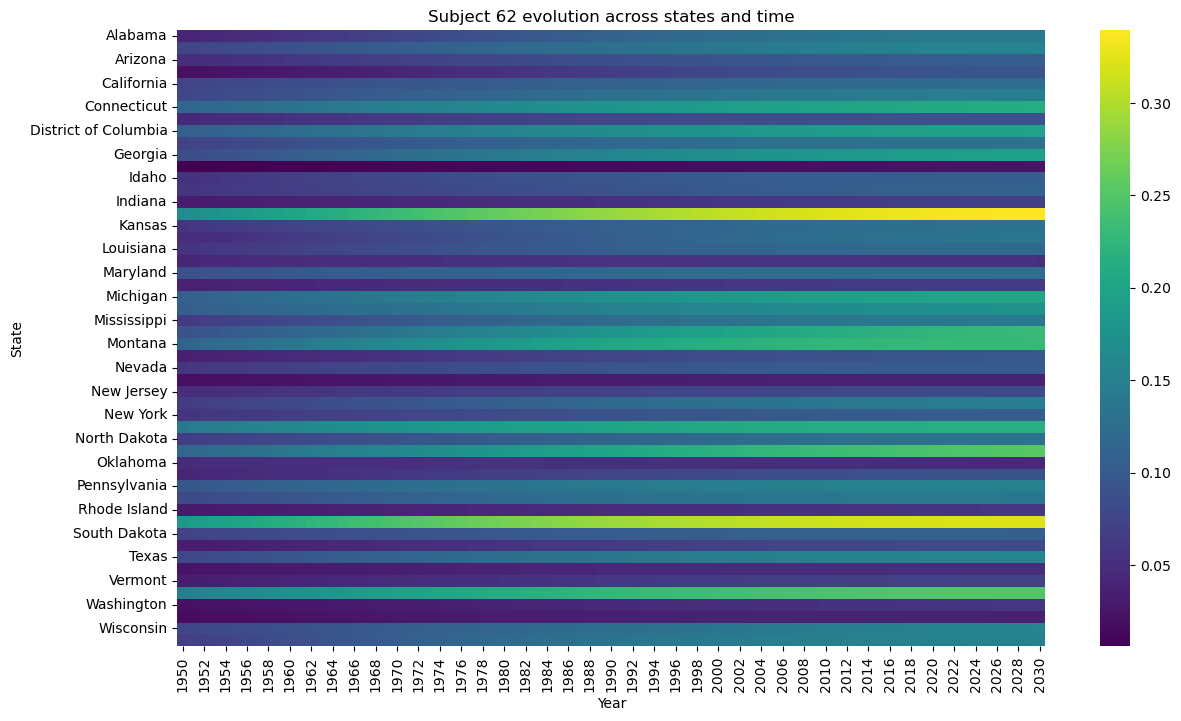

In [118]:
pivot = result.pivot_table(
    index="state",
    columns="year",
    values=subject
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="viridis")
plt.title(f"Subject {subject} evolution across states and time")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()